## Day 4
- So today I ended up adding the Momentum Trader Behavioral Subclass within the Agent Class which was much more neutral. It was previously actig on just random numerical differences between the Agents. Now I have tried to add concrete bbehavioral differences between the Agents by itroducing different type of Market players. I am starting with MomentumTrader and this experimet is done to obseve and understand those difference. 

In [29]:
import random
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
import pandas as pd

from agents.agent import Agent , MomentumTrader
from market.market import Market


### Creating Market

In [2]:
market_normal = Market(current_price=100, sensitivity=0.08)
market_momentum = Market(current_price=100, sensitivity=0.08)

### Creating Agents

In [3]:
normal_agents = []

for i in range(100):

    agent = Agent(
        identity=i,
        cash=random.randint(5000, 15000),
        holdings=random.randint(20, 100),
        risk_tolerance=random.uniform(0.2, 0.9)
    )

    normal_agents.append(agent)

### Creating Mixed Market Agents

In [4]:
mixed_agents = []

for i in range(70):

    agent = Agent(
        identity=i,
        cash = random.randint(8000, 12000),
        holdings = random.randint(80, 120),
        risk_tolerance=random.uniform(0.2, 0.9)
    )

    mixed_agents.append(agent)

for i in range(30):

    agent = MomentumTrader(
        identity=100+i,
        cash = random.randint(8000, 12000),
        holdings = random.randint(80, 120),
        risk_tolerance=random.uniform(0.3, 1.0)
    )

    mixed_agents.append(agent)

### Simulation Function

In [5]:
def run_simulation(market, agents, steps):

    previous_price = market.current_price

    for step in range(steps):

        actions = []

        price_movement = 0

        if step > 0:
            price_movement = (
                market.current_price - previous_price
            ) / previous_price

        previous_price = market.current_price

        for agent in agents:

            act, vol = agent.action(
                market.current_price,
                price_movement
            )

            actions.append((act, vol))

            agent.update_values(
                previous_price,
                market.current_price,
                act,
                vol
            )

        market.agents_act(actions)

        market.pricing()

### Running it for both markets


In [6]:
run_simulation(market_normal, normal_agents, 300)

run_simulation(market_momentum, mixed_agents, 300)


In [7]:
normal_prices = [
    x[0] for x in market_normal.price_history
]

momentum_prices = [
    x[0] for x in market_momentum.price_history
]

### Plot Comparison

In [8]:
normal_imbalance = [
    x[3] for x in market_normal.price_history
]

momentum_imbalance = [
    x[3] for x in market_momentum.price_history
]

In [9]:
normal_returns = [
    x[4] for x in market_normal.price_history
]

momentum_returns = [
    x[4] for x in market_momentum.price_history
]

In [10]:
normal_buy_pressure = [
    x[1] for x in market_normal.price_history
]

momentum_buy_pressure = [
    x[1] for x in market_momentum.price_history
]

In [11]:
normal_sell_pressure = [
    x[2] for x in market_normal.price_history
]

momentum_sell_pressure = [
    x[2] for x in market_momentum.price_history
]

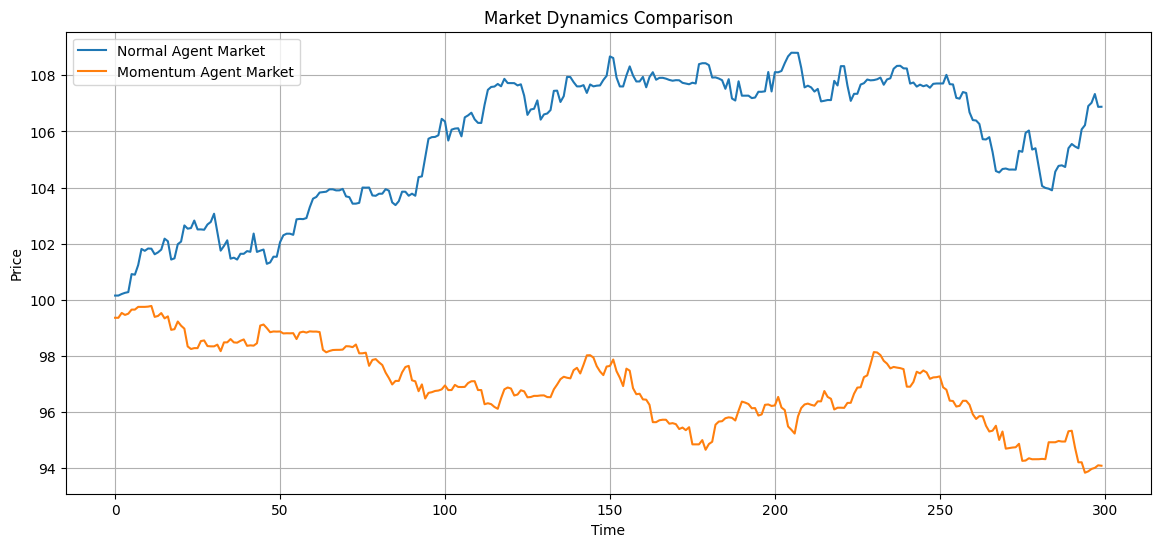

In [12]:
plt.figure(figsize=(14,6))

plt.plot(normal_prices, label="Normal Agent Market")

plt.plot(momentum_prices, label="Momentum Agent Market")

plt.title("Market Dynamics Comparison")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()


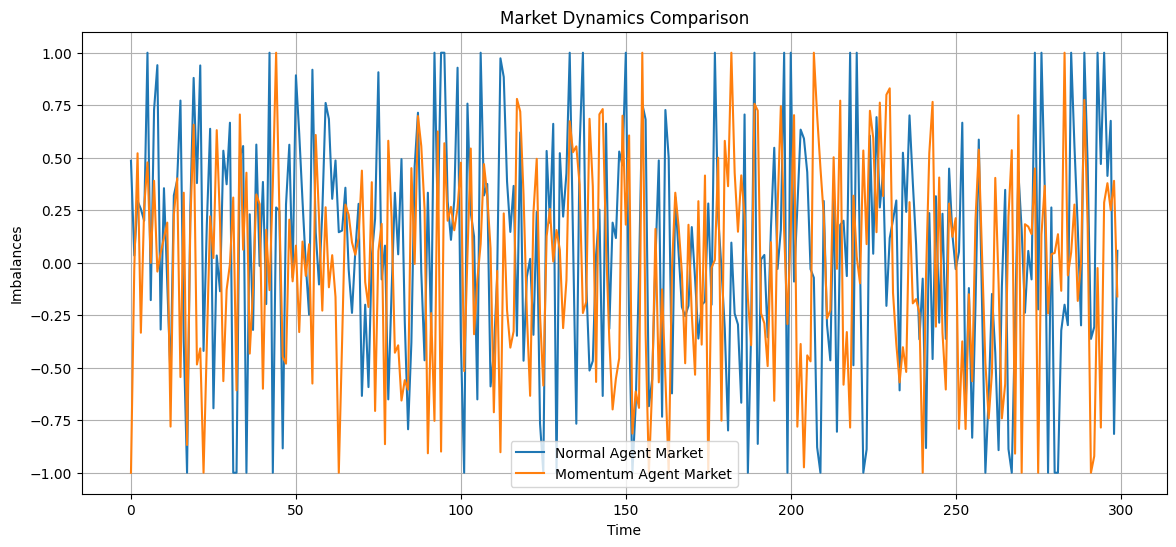

In [13]:
plt.figure(figsize=(14,6))

plt.plot(normal_imbalance, label="Normal Agent Market")

plt.plot(momentum_imbalance, label="Momentum Agent Market")

plt.title("Market Dynamics Comparison")
plt.xlabel("Time")
plt.ylabel("Imbalances")
plt.legend()
plt.grid()



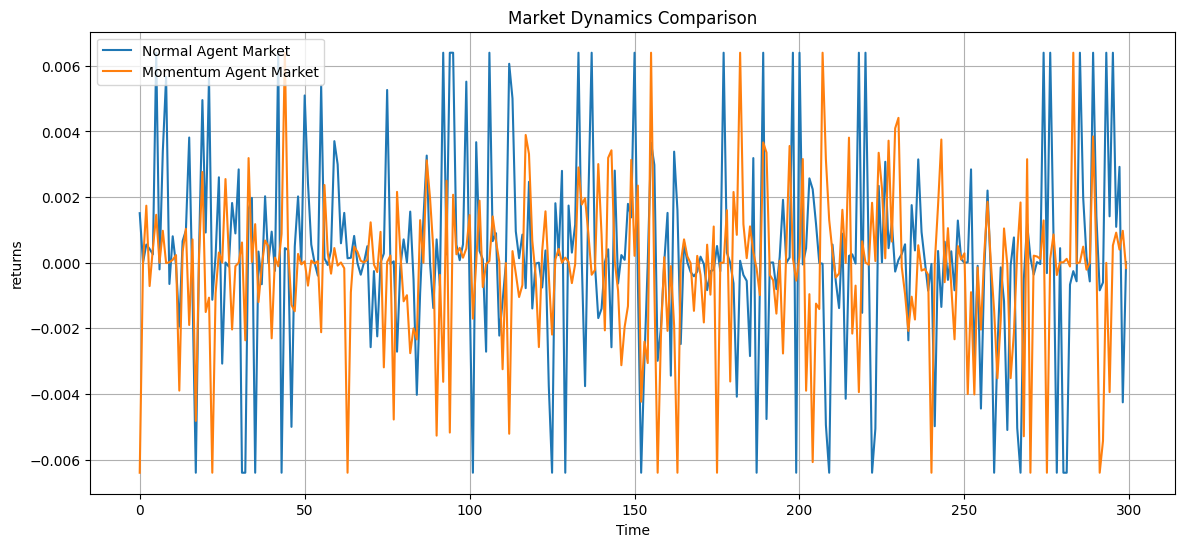

In [14]:
plt.figure(figsize=(14,6))

plt.plot(normal_returns, label="Normal Agent Market")

plt.plot(momentum_returns, label="Momentum Agent Market")

plt.title("Market Dynamics Comparison")
plt.xlabel("Time")
plt.ylabel("returns")
plt.legend()
plt.grid()

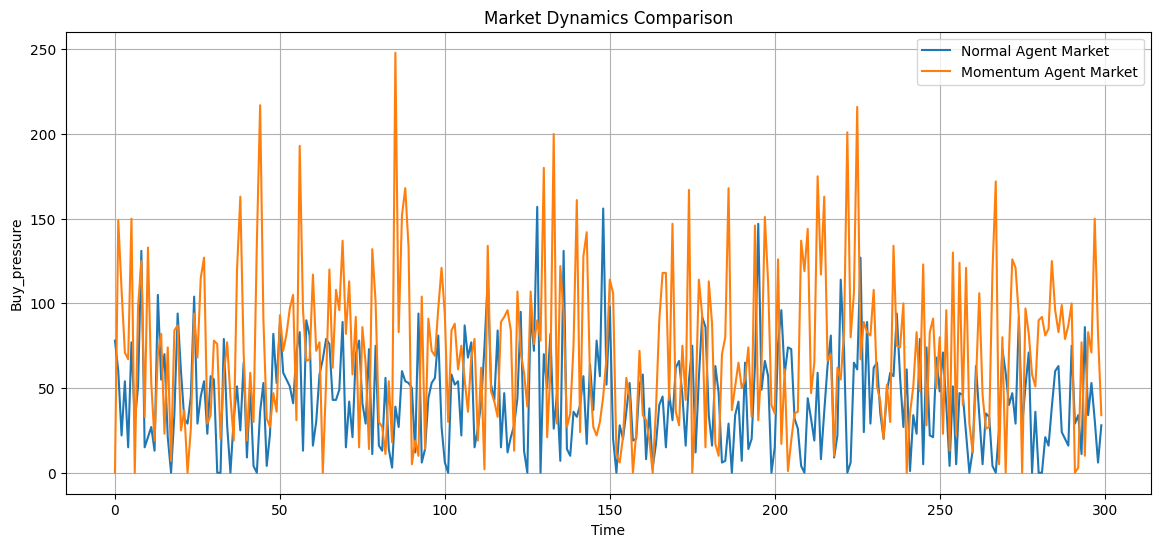

In [15]:
plt.figure(figsize=(14,6))

plt.plot(normal_buy_pressure, label="Normal Agent Market")

plt.plot(momentum_buy_pressure, label="Momentum Agent Market")

plt.title("Market Dynamics Comparison")
plt.xlabel("Time")
plt.ylabel("Buy_pressure")
plt.legend()
plt.grid()

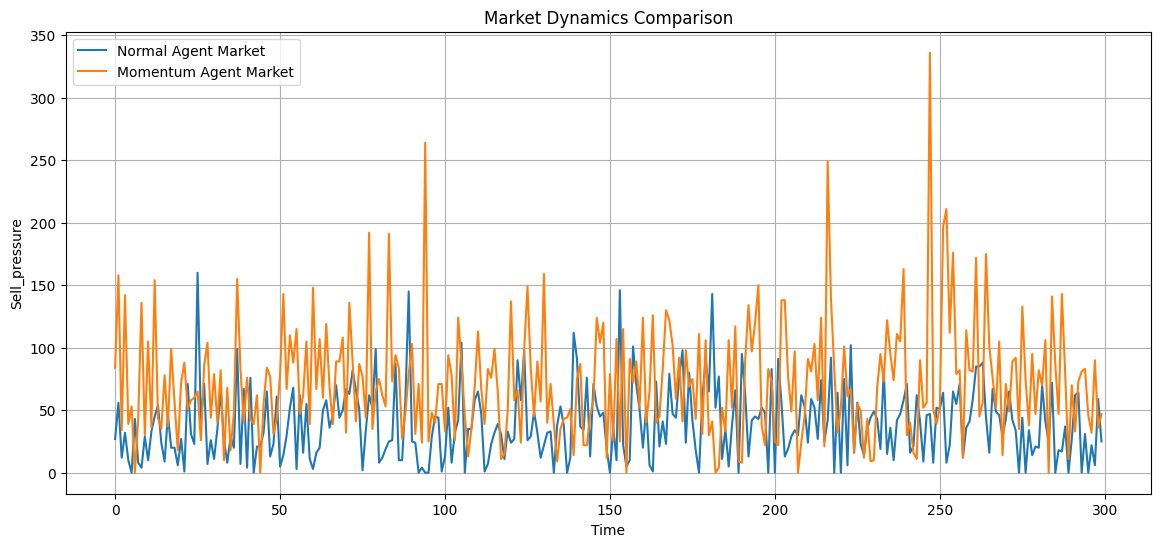

In [16]:
plt.figure(figsize=(14,6))

plt.plot(normal_sell_pressure, label="Normal Agent Market")

plt.plot(momentum_sell_pressure, label="Momentum Agent Market")

plt.title("Market Dynamics Comparison")
plt.xlabel("Time")
plt.ylabel("Sell_pressure")
plt.legend()
plt.grid()

### Observation - Behavioral Heterogeneity

Introducing MomentumTrader agents altered aggregate market behavior despite the pricing mechanism remaining unchanged.

The momentum-heavy market exhibited:

larger imbalance spikes
more volatile return bursts
different long-term price evolution

This was my first direct observation of emergent behavior arising from local decision rules


# Simulation Debugging Notes : Emergent Market Behavior

## Observation 1 : Buy/Sell Pressure Asymmetry

During the first simulation runs, buy pressure consistently dominated sell pressure numerically.

After inspection, I realized buy and sell volumes were being generated using fundamentally different scales:

* buy volume depended on cash/current_price
* sell volume depended only on holdings fraction

This unintentionally created structurally stronger buying pressure.

### Insight

Small implementation asymmetries can create persistent macro-level market bias.

---

## Observation 2 : Accidental Bullish Drift

The pricing function applied:

```python
returns = returns * returns
```

for small returns.

This removed directional sign information, causing negative returns to become positive.

As a result:
even bearish imbalance contributed upward price movement.

### Insight

Nonlinear transformations can unintentionally destroy critical behavioral information in simulations.

---

## Observation 3 : Behavioral Heterogeneity Produced Different Dynamics

Introducing MomentumTrader agents changed:

* imbalance structure
* return volatility
* aggregate price evolution

despite the pricing mechanism remaining identical.

### Insight

Local behavioral rules can propagate into visibly different macro market dynamics.

This was my first direct experience observing emergent behavior in a market simulation.

---

## Observation 4 : Architecture Validation

The subclass-based architecture successfully allowed behavioral modification without rewriting market mechanics.

Only `tendency()` needed overriding for MomentumTrader agents.

### Insight

Separating market mechanics from behavioral interpretation created a clean extensible simulation structure.



## Aim : implement rolling_std to observe the volatality... in different windows. 

 a lil confused whether I should import it from numpy or pandas... orr... maybe create it

In [26]:
def rolling_avg(returns, window):
    rolling_avg_val = 0
    for i in range(window):
        rolling_avg_val += returns[i]
        rolling_avg_val /= window

    rolling_avg_a = [ ]
    rolling_avg_a.append(rolling_avg_val)

    for i in range(window,len(returns) - window + 1):
        rolling_avg_val += (returns[i] - returns[i-window])/window
        rolling_avg_a.append(rolling_avg_val)
    
    return rolling_avg_a

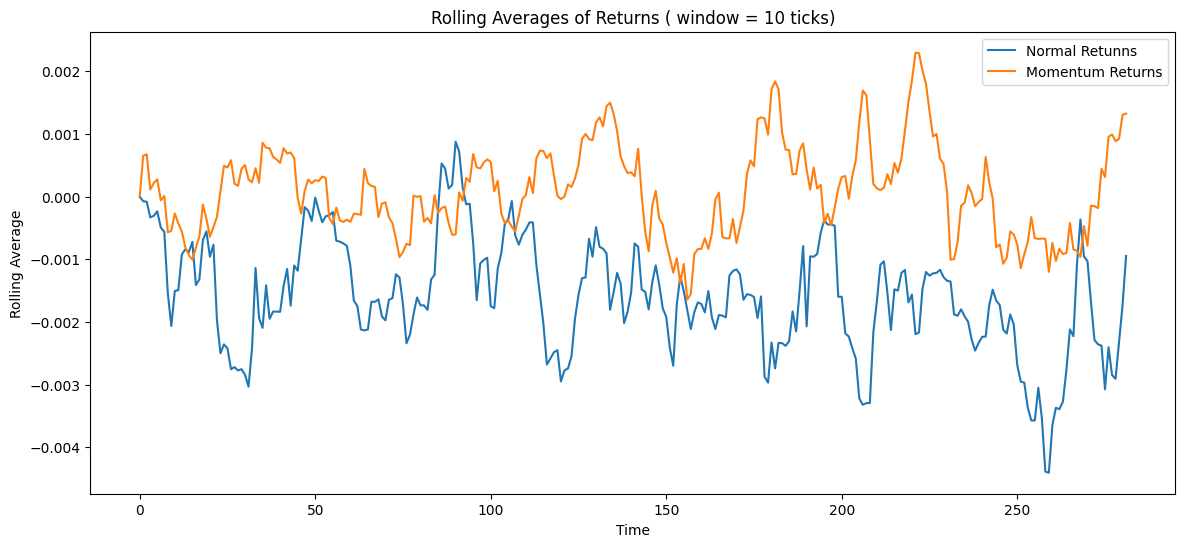

In [52]:
plt.figure(figsize= (14,6))
plt.plot(rolling_avg(normal_returns, 10), label = "Normal Retunns")
plt.plot(rolling_avg(momentum_returns, 10), label = "Momentum Returns")

plt.title("Rolling Averages of Returns ( window = 10 ticks)")
plt.xlabel("Time")
plt.ylabel("Rolling Average")

plt.legend()

In [61]:
returns_series = pd.Series(normal_returns)

rolling_vol_5 = returns_series.rolling(5).std()
rolling_vol_20 = returns_series.rolling(20).std()
rolling_vol_50 = returns_series.rolling(50).std()

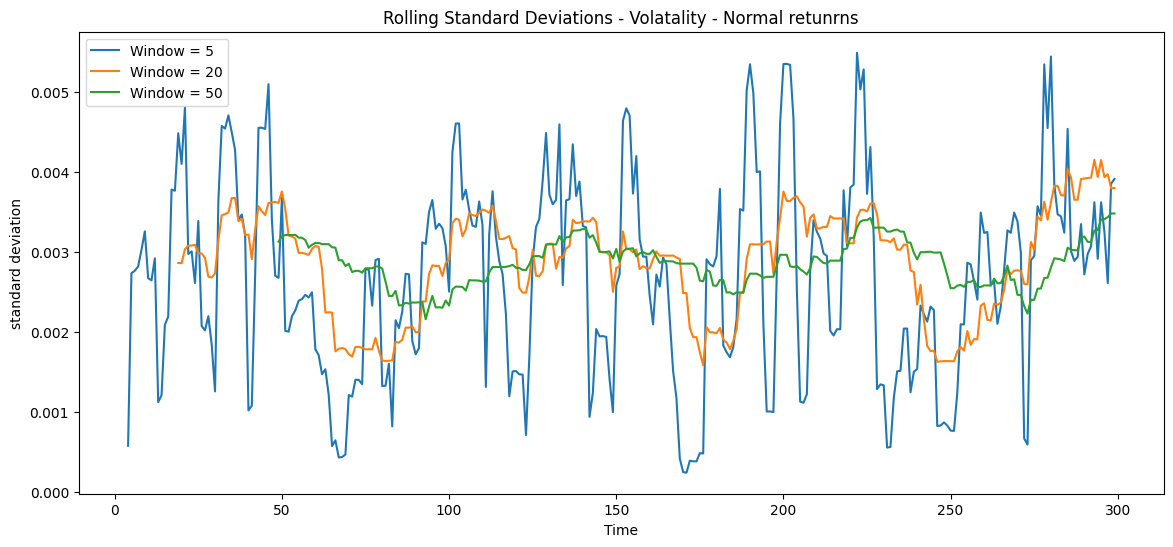

In [62]:
plt.figure(figsize=(14,6))
plt.plot(rolling_vol_5, label = "Window = 5")
plt.plot(rolling_vol_20, label = "Window = 20")
plt.plot(rolling_vol_50, label = "Window = 50")
plt.title("Rolling Standard Deviations - Volatality - Normal retunrns")
plt.xlabel("Time")
plt.ylabel("standard deviation")

plt.legend()

plt.savefig("../images/plots/momentum_v1_rolling_std_volatality.png")

In [63]:
returns_series = pd.Series(momentum_returns)

rolling_vol_5 = returns_series.rolling(5).std()
rolling_vol_20 = returns_series.rolling(20).std()
rolling_vol_50 = returns_series.rolling(50).std()

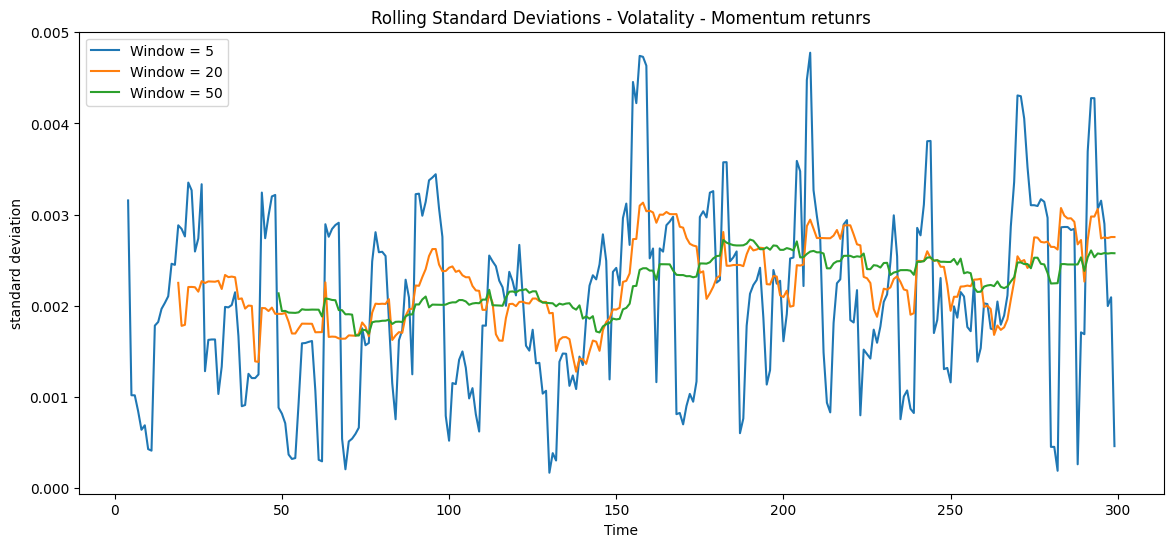

In [64]:
plt.figure(figsize=(14,6))
plt.plot(rolling_vol_5, label = "Window = 5")
plt.plot(rolling_vol_20, label = "Window = 20")
plt.plot(rolling_vol_50, label = "Window = 50")
plt.title("Rolling Standard Deviations - Volatality - Momentum retunrs")
plt.xlabel("Time")
plt.ylabel("standard deviation")

plt.legend()

plt.savefig("../images/plots/momentum_v1_rolling_std_volatality.png")

Volatality is Emerging now